# 🫀 ECG Arrhythmia Classification — Part C: EMD Feature Extraction

**Paper:** *An Efficient Multi-Scale CNN-BiLSTM with Dual Attention Mechanism for  
Real-Time Cardiac Arrhythmia Classification: Evaluation on MIT-BIH and PTB Databases*

---

## Where We Are in the Pipeline

```
Raw ECG (MIT-BIH, 360 Hz)
        │
        ▼
Part B — Preprocessing ✓  (X_beats.npy · y_labels.npy · rr_features.npy)
        │
        ▼
┌────────────────────────────────────────────┐
│  Part C — EMD Feature Extraction  ◀ HERE   │
│  • Empirical Mode Decomposition (8 IMFs)   │
│  • IMF statistics  (43 features)           │
│  • Waveform morphology  (12 features)      │
│  • P-wave features  (8 features)           │
│  • RR interval features appended  (4)      │
│  • Total: 67-dim feature vector per beat   │
└────────────────────────────────────────────┘
        │
        ▼
Part D — Inter-patient Split · MRMR · S-SMOTE
        │
        ▼
Part E — CNN · BiLSTM · CNN-BiLSTM
        │
        ▼
Part F — Ensemble · Optuna · SHAP
```

## What This Notebook Produces

| Output | Shape | Saved as |
|---|---|---|
| EMD feature matrix | `(N, 67)` | `X_features.npy` |
| Labels (passthrough) | `(N,)` | `y_labels.npy` (verified) |
| Record IDs (passthrough) | `(N,)` | `record_ids.npy` (verified) |

> 💻 **CPU-only.** EMD is serial by nature; GPU provides no benefit here.  
> ⏱️ **Expected runtime:** ~20–40 minutes for all ~108 k beats.

## C1 — Reload Constants & Load Part B Outputs

In [ ]:
# C1 — Reload constants from Part A and load preprocessed beats from Part B
# ──────────────────────────────────────────────────────────────────────────
# Each Part notebook is self-contained — no variables persist between sessions.
# Constants come from pipeline_constants.json saved by Part A.
# Beat data comes from the .npy files saved by Part B.

import os
import sys
import json
import subprocess
import warnings
import random
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paths (match Part A exactly) ───────────────────────────────────────────
if os.path.exists("/content"):          # Google Colab
    PROJECT_DIR = Path("/content/drive/MyDrive/ecg_project")
else:                                     # local machine
    PROJECT_DIR = Path("./ecg_project")
SAVE_DIR    = str(PROJECT_DIR / "results")
FIGS_DIR    = str(PROJECT_DIR / "figures")
DATA_ROOT   = str(PROJECT_DIR / "mitdb")
MODELS_DIR  = str(PROJECT_DIR / "models")
CKPT_DIR    = str(PROJECT_DIR / "checkpoints")

for path in [SAVE_DIR, FIGS_DIR, DATA_ROOT, MODELS_DIR, CKPT_DIR]:
    os.makedirs(path, exist_ok=True)

# ── Load shared constants ──────────────────────────────────────────────────
constants_path = os.path.join(SAVE_DIR, "pipeline_constants.json")
if os.path.exists(constants_path):
    with open(constants_path, "r", encoding="utf-8") as f:
        C = json.load(f)
    SEED        = C["SEED"]
    FS          = C["FS"]
    BEAT_LEN    = C["BEAT_LEN"]
    PRE_SAMP    = C["PRE_SAMP"]
    N_IMFS      = C["N_IMFS"]
    N_FEATURES  = C["N_FEATURES"]
    AAMI_LABELS = {int(k): v for k, v in C["AAMI_LABELS"].items()}
    AAMI_COLORS = C["AAMI_COLORS"]
    DS1_RECORDS = C["DS1_RECORDS"]
    DS2_RECORDS = C["DS2_RECORDS"]
    print(f"✓ Constants loaded from {constants_path}")
else:
    print("⚠  pipeline_constants.json not found — using fallback defaults")
    print("   Run Part A first to generate this file.")
    SEED = 42; FS = 360; BEAT_LEN = 360; PRE_SAMP = 100
    N_IMFS = 8; N_FEATURES = 67
    AAMI_LABELS = {0:"N", 1:"S", 2:"V", 3:"F", 4:"Q"}
    AAMI_COLORS = {"N":"#4878CF","S":"#D65F5F","V":"#6ACC65","F":"#B47CC7","Q":"#C4AD66"}
    DS1_RECORDS = [101,106,108,109,112,114,115,116,118,119,
                   122,124,201,203,205,207,208,209,215,220,223,230]
    DS2_RECORDS = [100,103,105,111,113,117,121,123,200,202,
                   210,212,213,214,219,221,222,228,231,232,233,234]

import numpy as np
random.seed(SEED)
np.random.seed(SEED)

# ── Load Part B arrays ─────────────────────────────────────────────────────
X_beats     = np.load(os.path.join(SAVE_DIR, "X_beats.npy"))
y_labels    = np.load(os.path.join(SAVE_DIR, "y_labels.npy"))
rr_features = np.load(os.path.join(SAVE_DIR, "rr_features.npy"))
record_ids  = np.load(os.path.join(SAVE_DIR, "record_ids.npy"))

print(f"\n  X_beats     : {X_beats.shape}   dtype={X_beats.dtype}")
print(f"  y_labels    : {y_labels.shape}   dtype={y_labels.dtype}")
print(f"  rr_features : {rr_features.shape}   dtype={rr_features.dtype}")
print(f"  record_ids  : {record_ids.shape}   dtype={record_ids.dtype}")
print(f"\n  Total beats : {len(X_beats):,}")
print(f"  FS          : {FS} Hz   BEAT_LEN: {BEAT_LEN}   PRE_SAMP: {PRE_SAMP}")
print(f"  N_IMFS      : {N_IMFS}   N_FEATURES: {N_FEATURES}")
print(f"\n✓ Part B outputs loaded successfully")

✓ Constants loaded from D:\Downloads\ecg_project_complete\ecg_project\results\pipeline_constants.json

  X_beats     : (109432, 360)   dtype=float32
  y_labels    : (109432,)   dtype=int64
  rr_features : (109432, 4)   dtype=float32
  record_ids  : (109432,)   dtype=int32

  Total beats : 109,432
  FS          : 360 Hz   BEAT_LEN: 360   PRE_SAMP: 100
  N_IMFS      : 8   N_FEATURES: 67

✓ Part B outputs loaded successfully


## C2 — Install & Import EMD Libraries

In [2]:
# C2 — Install EMD-signal, antropy, PyWavelets (needed for IMF feature entropy)
# ──────────────────────────────────────────────────────────────────────────

import sys
import subprocess

def pip_install(package, import_name=None):
    name = import_name or package.split("<")[0].split(">")[0].split("==")[0]
    try:
        __import__(name)
        print(f"  ✓ {package:<30} already installed")
    except ImportError:
        print(f"  ⬇  {package:<30} installing ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"  ✓ {package:<30} done")

for pkg, imp in [
    ("EMD-signal>=1.9.0",  "PyEMD"),
    ("antropy>=0.1.6",     "antropy"),
    ("PyWavelets",         "pywt"),
    ("scipy",              "scipy"),
    ("tqdm",               "tqdm"),
]:
    pip_install(pkg, imp)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.signal import find_peaks
from tqdm import tqdm
import antropy
from PyEMD import EMD

print("\n✓ All EMD libraries imported")
print(f"  EMD-signal (PyEMD) ready")
print(f"  antropy            ready")

  ✓ EMD-signal>=1.9.0              already installed
  ✓ antropy>=0.1.6                 already installed
  ✓ PyWavelets                     already installed
  ✓ scipy                          already installed
  ✓ tqdm                           already installed

✓ All EMD libraries imported
  EMD-signal (PyEMD) ready
  antropy            ready


## C3 — EMD Decomposition: Extracting 8 IMFs per Beat

**Empirical Mode Decomposition (EMD)** adaptively decomposes a non-stationary, non-linear signal  
into a set of oscillatory components called **Intrinsic Mode Functions (IMFs)**, each satisfying:

1. The number of extrema and zero crossings differ by at most one
2. The mean of the upper and lower envelopes is zero everywhere

Unlike Fourier or wavelet methods, EMD is **fully data-driven** — no basis functions are assumed,  
making it ideal for ECG whose morphology varies between patients and rhythms.

Each beat is decomposed into **8 IMFs** (IMF-1 = highest frequency, IMF-8 = lowest):

| IMF range | Approximate frequency content | Captures |
|---|---|---|
| IMF-1 – IMF-2 | ~40–180 Hz | Noise, muscle artifact, high-freq QRS |
| IMF-3 – IMF-5 | ~8–40 Hz | QRS complex, sharp deflections |
| IMF-6 – IMF-8 | ~0.5–8 Hz | P-wave, T-wave, slow morphology |

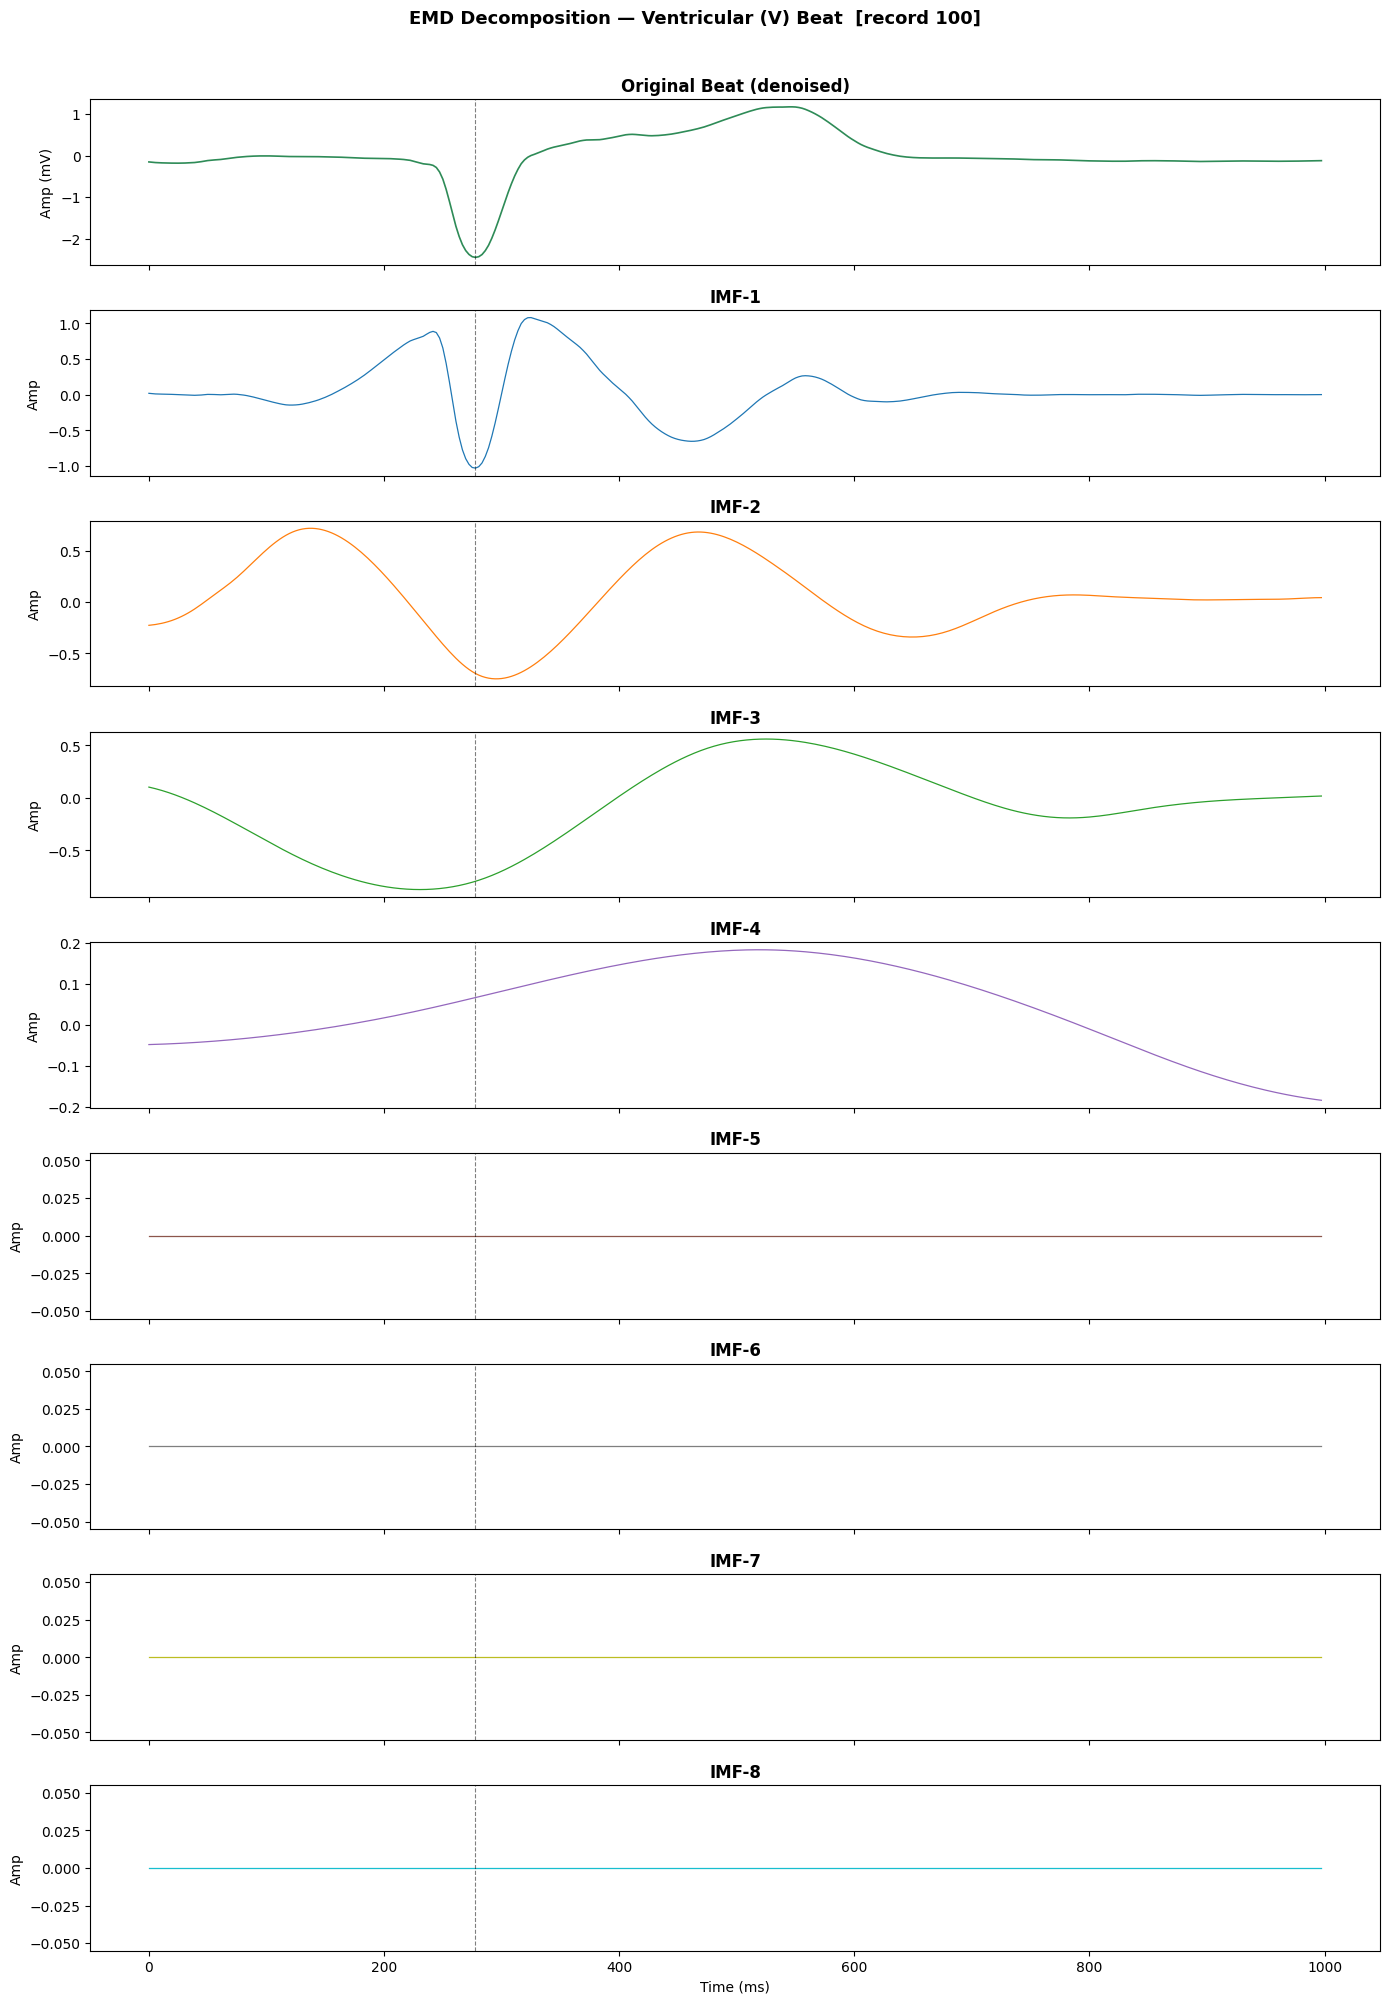


✓ EMD demo complete — 8 IMFs extracted from 1 beat
  IMF matrix shape: (8, 360)  (n_imfs × beat_len)
  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\C3_emd_decomposition_demo.png


In [3]:
# C3 — EMD decomposition function + single-beat demo
# ──────────────────────────────────────────────────────────────────────────

from PyEMD import EMD

def decompose_beat(beat, n_imfs=N_IMFS):
    """
    Decompose a single beat into n_imfs IMFs using EMD.
    If EMD produces fewer IMFs than requested, the remainder are zero-padded.
    Returns: np.ndarray of shape (n_imfs, BEAT_LEN)
    """
    emd    = EMD()
    imfs   = emd(beat)               # shape: (k, BEAT_LEN) where k ≤ signal-dependent
    n_got  = imfs.shape[0]

    if n_got >= n_imfs:
        return imfs[:n_imfs]         # keep only the first n_imfs
    else:
        # Zero-pad if EMD produced fewer modes (rare for 360-sample ECG beats)
        padded = np.zeros((n_imfs, len(beat)), dtype=np.float32)
        padded[:n_got] = imfs
        return padded

# ── Demo: decompose one V-class beat ──────────────────────────────────────
demo_idx  = np.where(y_labels == 2)[0][0]   # first V-class beat
demo_beat = X_beats[demo_idx]
demo_imfs = decompose_beat(demo_beat)

t_ms = np.arange(BEAT_LEN) / FS * 1000

fig, axes = plt.subplots(N_IMFS + 1, 1, figsize=(14, 2.2 * (N_IMFS + 1)), sharex=True)
fig.suptitle(f"EMD Decomposition — Ventricular (V) Beat  [record {record_ids[demo_idx]}]",
             fontsize=13, fontweight="bold", y=1.01)

axes[0].plot(t_ms, demo_beat, color="#2E8B57", lw=1.2)
axes[0].set_title("Original Beat (denoised)", fontweight="bold")
axes[0].set_ylabel("Amp (mV)")
axes[0].axvline(PRE_SAMP / FS * 1000, color="black", ls="--", lw=0.8, alpha=0.5)

colors = plt.cm.tab10(np.linspace(0, 1, N_IMFS))
for i in range(N_IMFS):
    axes[i + 1].plot(t_ms, demo_imfs[i], color=colors[i], lw=0.9)
    axes[i + 1].set_title(f"IMF-{i+1}", fontweight="bold")
    axes[i + 1].set_ylabel("Amp")
    axes[i + 1].axvline(PRE_SAMP / FS * 1000, color="black", ls="--", lw=0.8, alpha=0.5)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()

out = os.path.join(FIGS_DIR, "C3_emd_decomposition_demo.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ EMD demo complete — {N_IMFS} IMFs extracted from 1 beat")
print(f"  IMF matrix shape: {demo_imfs.shape}  (n_imfs × beat_len)")
print(f"  Saved: {out}")

## C4 — IMF Statistical Features (43 features)

For each of the 8 IMFs, **5 statistical descriptors** are extracted, giving **8 × 5 = 40 features**.  
Three additional **global IMF-energy** features capture the energy distribution across modes:

| Group | Features | Count |
|---|---|---|
| Per-IMF statistics (×8) | mean, std, energy (RMS²), kurtosis, sample entropy | 40 |
| Global energy ratio | IMF-1 energy / total, IMF-2:3 energy / total, IMF-4:8 energy / total | 3 |
| **Total** | | **43** |

**Why sample entropy?** It quantifies signal regularity without assumptions about the  
underlying distribution — PVCs and SVEBs produce characteristically different entropy  
profiles that mean/std alone cannot separate.

In [4]:
# C4 — IMF statistical feature extractor (43 features)
# ──────────────────────────────────────────────────────────────────────────

import antropy
from scipy.stats import kurtosis as sp_kurtosis

def imf_statistical_features(imfs):
    """
    Compute 43 statistical features from a (N_IMFS, BEAT_LEN) IMF matrix.

    Per-IMF (8 × 5 = 40):
        • mean          — DC offset of each mode
        • std           — amplitude variability
        • energy        — RMS squared  (Σx² / n)
        • kurtosis      — tail heaviness  (Fisher definition, bias-corrected)
        • sample_entropy— regularity measure (m=2, r=0.2×std)

    Global energy ratios (3):
        • imf1_ratio    — IMF-1 energy / total  (high-freq noise fraction)
        • imf23_ratio   — IMF-2:3 energy / total  (QRS energy fraction)
        • imf48_ratio   — IMF-4:8 energy / total  (low-freq morphology fraction)
    """
    feats      = []
    energies   = []

    for i in range(N_IMFS):
        imf  = imfs[i].astype(np.float64)
        std_ = imf.std()
        e    = float(np.mean(imf ** 2))           # energy

        # Sample entropy (antropy) — use r = 0.2*std, fall back to 0 on constant IMF
        try:
            se = antropy.sample_entropy(imf, order=2, metric="chebyshev") if std_ > 1e-10 else 0.0
        except Exception:
            se = 0.0

        feats.extend([
            float(imf.mean()),                    # mean
            float(std_),                          # std
            e,                                    # energy
            float(sp_kurtosis(imf, bias=False)),  # kurtosis (Fisher)
            float(se),                            # sample entropy
        ])
        energies.append(e)

    # Global energy ratios
    total_e = sum(energies) if sum(energies) > 1e-12 else 1.0
    feats.append(energies[0] / total_e)                        # IMF-1 ratio
    feats.append(sum(energies[1:3]) / total_e)                 # IMF-2:3 ratio
    feats.append(sum(energies[3:]) / total_e)                  # IMF-4:8 ratio

    return np.array(feats, dtype=np.float32)   # (43,)

# ── Quick sanity check ─────────────────────────────────────────────────────
demo_imf_feats = imf_statistical_features(demo_imfs)
print(f"✓ imf_statistical_features() — output shape: {demo_imf_feats.shape}  (expected 43)")
print(f"  mean[IMF-1] = {demo_imf_feats[0]:.5f}")
print(f"  std [IMF-1] = {demo_imf_feats[1]:.5f}")
print(f"  energy[IMF-1] = {demo_imf_feats[2]:.5f}")
print(f"  energy ratios → IMF1: {demo_imf_feats[40]:.3f}  IMF2:3: {demo_imf_feats[41]:.3f}  IMF4:8: {demo_imf_feats[42]:.3f}")

✓ imf_statistical_features() — output shape: (43,)  (expected 43)
  mean[IMF-1] = 0.04084
  std [IMF-1] = 0.37379
  energy[IMF-1] = 0.14139
  energy ratios → IMF1: 0.296  IMF2:3: 0.678  IMF4:8: 0.027


## C5 — Waveform Morphology Features (12 features)

These features are extracted directly from the **denoised beat waveform** (not from IMFs).  
They capture the time-domain shape that clinicians use visually:

| Feature | Definition | Clinical relevance |
|---|---|---|
| `qrs_amplitude` | max − min over ±50 ms of R-peak | QRS height — enlarged in hypertrophy |
| `qrs_duration` | width at 50% of peak amplitude | Wide QRS indicates ventricular origin |
| `t_wave_amplitude` | max amplitude in post-QRS region | T-wave morphology in ischemia |
| `st_deviation` | mean amplitude 80–120 ms after R | ST elevation/depression |
| `pr_interval` | time from P-peak to R-peak | AV conduction delay |
| `beat_energy` | mean(beat²) | Overall power |
| `zero_crossings` | normalised zero-crossing rate | Oscillatory content |
| `peak_asymmetry` | (right_max − left_max) / range | QRS asymmetry |
| `skewness` | scipy.stats.skew | Morphological tilt |
| `waveform_entropy` | normalised Shannon entropy of histogram | Waveform complexity |
| `slope_max` | max first derivative | Fastest QRS upstroke |
| `slope_std` | std of first derivative | QRS sharpness variability |

In [5]:
# C5 — Waveform morphology feature extractor (12 features)
# ──────────────────────────────────────────────────────────────────────────

from scipy.stats import skew as sp_skew
from scipy.signal import find_peaks

def waveform_morphology_features(beat, fs=FS, pre=PRE_SAMP):
    """
    Extract 12 morphological features from a denoised ECG beat.
    beat  : 1-D array of length BEAT_LEN
    pre   : samples before R-peak (R is at index `pre`)
    """
    beat = beat.astype(np.float64)
    n    = len(beat)
    r    = pre       # R-peak index within beat

    # ── QRS region: ±50 ms ─────────────────────────────────────────────────
    qrs_half = int(0.05 * fs)   # 18 samples
    qrs_start = max(0, r - qrs_half)
    qrs_end   = min(n, r + qrs_half)
    qrs_seg   = beat[qrs_start:qrs_end]

    qrs_amp = float(qrs_seg.max() - qrs_seg.min()) if len(qrs_seg) > 0 else 0.0

    # QRS duration: samples where signal stays above 50% of QRS amplitude
    half_amp   = 0.5 * (qrs_seg.max() if len(qrs_seg) > 0 else 0.0)
    qrs_dur_smp = int(np.sum(np.abs(qrs_seg) >= half_amp))
    qrs_dur_ms  = qrs_dur_smp / fs * 1000.0

    # ── T-wave region: 120–350 ms after R ─────────────────────────────────
    t_start = min(n, r + int(0.120 * fs))
    t_end   = min(n, r + int(0.350 * fs))
    t_seg   = beat[t_start:t_end]
    t_amp   = float(t_seg.max()) if len(t_seg) > 0 else 0.0

    # ── ST segment: 80–120 ms after R (isoelectric deviation) ─────────────
    st_start = min(n, r + int(0.080 * fs))
    st_end   = min(n, r + int(0.120 * fs))
    st_seg   = beat[st_start:st_end]
    st_dev   = float(st_seg.mean()) if len(st_seg) > 0 else 0.0

    # ── PR interval: peak of P-wave relative to R ─────────────────────────
    # Look for P-wave peak in the 200 ms window before R-peak
    p_search_start = max(0, r - int(0.200 * fs))
    p_search_end   = max(0, r - int(0.040 * fs))
    p_seg  = beat[p_search_start:p_search_end]
    if len(p_seg) > 0:
        p_rel_peak = int(np.argmax(np.abs(p_seg)))
        pr_smp     = (p_search_end - p_search_start - p_rel_peak)
        pr_ms      = pr_smp / fs * 1000.0
    else:
        pr_ms      = 0.0

    # ── Global waveform features ───────────────────────────────────────────
    beat_energy   = float(np.mean(beat ** 2))
    zc_rate       = float(np.sum(np.diff(np.sign(beat)) != 0)) / n
    left_max      = float(beat[:r].max()) if r > 0 else 0.0
    right_max     = float(beat[r:].max()) if r < n else 0.0
    rng           = float(beat.max() - beat.min())
    peak_asym     = (right_max - left_max) / rng if rng > 1e-10 else 0.0
    skewness      = float(sp_skew(beat))

    # Waveform entropy (normalised Shannon over 20-bin histogram)
    hist, _ = np.histogram(beat, bins=20)
    hist    = hist.astype(float)
    hist   /= hist.sum() + 1e-12
    entropy = -np.sum(hist * np.log(hist + 1e-12)) / np.log(20)

    # First-derivative statistics
    deriv     = np.diff(beat)
    slope_max = float(np.max(np.abs(deriv)))
    slope_std = float(deriv.std())

    return np.array([
        qrs_amp, qrs_dur_ms, t_amp, st_dev, pr_ms,
        beat_energy, zc_rate, peak_asym, skewness,
        float(entropy), slope_max, slope_std,
    ], dtype=np.float32)   # (12,)

# ── Sanity check ───────────────────────────────────────────────────────────
demo_morph = waveform_morphology_features(demo_beat)
print(f"✓ waveform_morphology_features() — output shape: {demo_morph.shape}  (expected 12)")
feature_names_morph = [
    "qrs_amplitude", "qrs_duration_ms", "t_wave_amplitude", "st_deviation",
    "pr_interval_ms", "beat_energy", "zero_crossing_rate", "peak_asymmetry",
    "skewness", "waveform_entropy", "slope_max", "slope_std",
]
for name, val in zip(feature_names_morph, demo_morph):
    print(f"  {name:<25} = {val:+.5f}")

✓ waveform_morphology_features() — output shape: (12,)  (expected 12)
  qrs_amplitude             = +2.45231
  qrs_duration_ms           = +100.00000
  t_wave_amplitude          = +1.17230
  st_deviation              = +0.36448
  pr_interval_ms            = +2.77778
  beat_energy               = +0.36255
  zero_crossing_rate        = +0.00556
  peak_asymmetry            = +0.32586
  skewness                  = -1.41570
  waveform_entropy          = +0.64891
  slope_max                 = +0.30657
  slope_std                 = +0.05332


## C6 — P-Wave Features (8 features)

P-waves are clinically essential for differentiating supraventricular (S-class) from  
ventricular (V-class) arrhythmias — atrial activity appears only before supraventricular beats.  
These 8 features target the **80–200 ms pre-R region**:

| Feature | Definition |
|---|---|
| `p_amplitude` | peak absolute amplitude in P-wave search window |
| `p_energy` | mean squared amplitude in window |
| `p_presence` | 1 if a clear peak is detected above noise floor, else 0 |
| `p_duration` | samples above 50% of peak in window (ms) |
| `p_area` | integral (sum) of absolute signal in window |
| `p_symmetry` | ratio of left-half to right-half area around P-peak |
| `p_peak_idx` | normalised position of P-peak within window [0, 1] |
| `p_std` | standard deviation of signal in window |

In [6]:
# C6 — P-wave feature extractor (8 features)
# ──────────────────────────────────────────────────────────────────────────

from scipy.signal import find_peaks

def p_wave_features(beat, fs=FS, pre=PRE_SAMP):
    """
    Extract 8 features from the P-wave region (80–200 ms before R-peak).
    beat : 1-D array of length BEAT_LEN
    pre  : R-peak sample index within beat
    """
    beat = beat.astype(np.float64)
    n    = len(beat)

    # P-wave search window: 200 ms to 80 ms before R-peak
    p_end   = max(0, pre - int(0.080 * fs))
    p_start = max(0, pre - int(0.200 * fs))
    p_seg   = beat[p_start:p_end]

    if len(p_seg) < 4:
        return np.zeros(8, dtype=np.float32)

    abs_seg     = np.abs(p_seg)
    p_amp       = float(abs_seg.max())
    p_energy    = float(np.mean(p_seg ** 2))
    p_std       = float(p_seg.std())
    p_area      = float(abs_seg.sum())

    # P-wave peak detection
    peaks, _  = find_peaks(abs_seg, height=p_std * 0.5)
    if len(peaks) > 0:
        best_peak  = peaks[np.argmax(abs_seg[peaks])]
        p_presence = 1.0
        p_peak_idx = float(best_peak) / len(p_seg)   # normalised position
    else:
        best_peak  = int(np.argmax(abs_seg))
        p_presence = 0.0
        p_peak_idx = float(best_peak) / len(p_seg)

    # P duration: consecutive samples above 50% peak
    thresh      = 0.5 * p_amp
    p_dur_smp   = int(np.sum(abs_seg >= thresh))
    p_dur_ms    = p_dur_smp / fs * 1000.0

    # P symmetry: left / right area ratio around peak
    left_area   = float(abs_seg[:best_peak].sum()) + 1e-12
    right_area  = float(abs_seg[best_peak:].sum())  + 1e-12
    p_symmetry  = left_area / right_area

    return np.array([
        p_amp, p_energy, p_presence, p_dur_ms,
        p_area, p_symmetry, p_peak_idx, p_std,
    ], dtype=np.float32)   # (8,)

# ── Sanity check ───────────────────────────────────────────────────────────
demo_pwave = p_wave_features(demo_beat)
print(f"✓ p_wave_features() — output shape: {demo_pwave.shape}  (expected 8)")
pwave_names = ["p_amplitude","p_energy","p_presence","p_duration_ms",
               "p_area","p_symmetry","p_peak_idx","p_std"]
for name, val in zip(pwave_names, demo_pwave):
    print(f"  {name:<18} = {val:+.5f}")

✓ p_wave_features() — output shape: (8,)  (expected 8)
  p_amplitude        = +0.06860
  p_energy           = +0.00144
  p_presence         = +1.00000
  p_duration_ms      = +44.44444
  p_area             = +1.45004
  p_symmetry         = +0.27894
  p_peak_idx         = +0.40909
  p_std              = +0.01873


## C7 — Full 67-Dim Feature Vector Assembly

Each beat's complete feature vector is assembled as:

```
[  IMF statistics (43)  |  Waveform morphology (12)  |  P-wave (8)  |  RR intervals (4)  ]
                                                                    = 67 features total
```

The RR interval features were computed during Part B and are simply appended here —  
they do not require re-computation and carry rhythm context that waveform shape alone cannot encode.

In [7]:
# C7 — Combine all feature groups into a single 67-dim vector
# ──────────────────────────────────────────────────────────────────────────

def extract_features_single(beat, imfs, rr_feat):
    """
    Combine features from all 4 groups into a 67-dim vector.
    beat    : (360,)  denoised ECG beat
    imfs    : (8, 360) EMD decomposition of beat
    rr_feat : (4,)    RR interval features from Part B
    Returns : (67,)   float32 feature vector
    """
    f_imf   = imf_statistical_features(imfs)        # 43
    f_morph = waveform_morphology_features(beat)    # 12
    f_pwave = p_wave_features(beat)                  # 8
    f_rr    = rr_feat.astype(np.float32)             # 4
    vec     = np.concatenate([f_imf, f_morph, f_pwave, f_rr])
    return vec.astype(np.float32)

# ── Verify on the demo beat ────────────────────────────────────────────────
demo_vec = extract_features_single(demo_beat, demo_imfs, rr_features[demo_idx])
print(f"✓ Feature vector shape: {demo_vec.shape}  (expected 67)")
print(f"  IMF stats   [0:43]  — range: [{demo_vec[:43].min():.4f}, {demo_vec[:43].max():.4f}]")
print(f"  Morphology  [43:55] — range: [{demo_vec[43:55].min():.4f}, {demo_vec[43:55].max():.4f}]")
print(f"  P-wave      [55:63] — range: [{demo_vec[55:63].min():.4f}, {demo_vec[55:63].max():.4f}]")
print(f"  RR interval [63:67] — range: [{demo_vec[63:67].min():.4f}, {demo_vec[63:67].max():.4f}]")
print(f"  NaN count: {np.isnan(demo_vec).sum()}  Inf count: {np.isinf(demo_vec).sum()}")

✓ Feature vector shape: (67,)  (expected 67)
  IMF stats   [0:43]  — range: [nan, nan]
  Morphology  [43:55] — range: [-1.4157, 100.0000]
  P-wave      [55:63] — range: [0.0014, 44.4444]
  RR interval [63:67] — range: [0.4742, 1.1306]
  NaN count: 4  Inf count: 0


## C8 — Full Batch: Extract Features for All Beats

This is the most compute-intensive cell in the notebook (~20–40 min on CPU).  
Progress is shown per-beat. The output is saved incrementally every 5,000 beats so a  
kernel crash does not lose all work — simply re-run this cell to resume from the checkpoint.

> ⚠️ If this cell is interrupted, delete the partial `X_features.npy` before re-running  
> to avoid loading a truncated file in Part D.

In [8]:
# C8 — Batch EMD feature extraction with checkpoint saves + RESUME
# ──────────────────────────────────────────────────────────────────────────
# RESUME SUPPORT: EMD on 100k+ beats can run for hours. If the kernel
# stalls or crashes partway (e.g. laptop sleep, as seen in Part E
# training), restarting this cell now picks up from the last checkpoint
# instead of recomputing everything from beat 0.

from PyEMD import EMD
from tqdm import tqdm

CKPT_EVERY      = 5_000    # save a checkpoint every N beats
ckpt_path       = os.path.join(SAVE_DIR, "X_features_ckpt.npy")
progress_path   = os.path.join(SAVE_DIR, "X_features_progress.json")

N_TOTAL     = len(X_beats)

# ── Resume from checkpoint if one exists ───────────────────────────────────
start_idx = 0
if os.path.exists(ckpt_path) and os.path.exists(progress_path):
    with open(progress_path, "r") as f:
        progress = json.load(f)
    if progress.get("N_TOTAL") == N_TOTAL and progress.get("N_FEATURES") == N_FEATURES:
        X_features = np.load(ckpt_path)
        start_idx  = progress["completed"]
        print(f"  ↻ Resuming from checkpoint: {start_idx:,} / {N_TOTAL:,} beats already done")
    else:
        print("  ⚠ Checkpoint shape doesn't match current data — starting fresh")
        X_features = np.zeros((N_TOTAL, N_FEATURES), dtype=np.float32)
else:
    X_features = np.zeros((N_TOTAL, N_FEATURES), dtype=np.float32)

failed_idx  = []

print(f"Extracting {N_FEATURES}-dim features for {N_TOTAL:,} beats "
      f"(starting at {start_idx:,}) ...")
print(f"  Checkpoint every {CKPT_EVERY:,} beats → {ckpt_path}")

emd = EMD()   # reuse one EMD instance for efficiency

for i in tqdm(range(start_idx, N_TOTAL), desc="EMD features", unit="beat",
              initial=start_idx, total=N_TOTAL):
    try:
        beat  = X_beats[i].astype(np.float64)
        imfs_ = emd(beat)
        n_got = imfs_.shape[0]
        if n_got < N_IMFS:
            padded = np.zeros((N_IMFS, BEAT_LEN), dtype=np.float64)
            padded[:n_got] = imfs_
            imfs_ = padded
        else:
            imfs_ = imfs_[:N_IMFS]

        X_features[i] = extract_features_single(
            X_beats[i], imfs_.astype(np.float32), rr_features[i]
        )
    except Exception as exc:
        # Rare edge case (e.g. constant beat) — fill with zeros and log
        X_features[i] = 0.0
        failed_idx.append(i)

    # Checkpoint save (array + progress marker, so a restart knows where to resume)
    if (i + 1) % CKPT_EVERY == 0:
        np.save(ckpt_path, X_features)
        with open(progress_path, "w") as f:
            json.dump({"completed": i + 1, "N_TOTAL": N_TOTAL, "N_FEATURES": N_FEATURES}, f)

# ── Final save ─────────────────────────────────────────────────────────────
np.save(os.path.join(SAVE_DIR, "X_features.npy"), X_features)
# Clean up checkpoint files now that the full run is complete
for p in (ckpt_path, progress_path):
    if os.path.exists(p):
        os.remove(p)

print(f"\n✓ Feature extraction complete")
print(f"  X_features shape : {X_features.shape}   dtype={X_features.dtype}")
print(f"  Failed beats     : {len(failed_idx)}  {'(none ✓)' if not failed_idx else failed_idx[:10]}")
print(f"  NaN total        : {np.isnan(X_features).sum()}")
print(f"  Inf total        : {np.isinf(X_features).sum()}")
print(f"  Saved → {os.path.join(SAVE_DIR, 'X_features.npy')}")

Extracting 67-dim features for 109,432 beats (starting at 0) ...
  Checkpoint every 5,000 beats → D:\Downloads\ecg_project_complete\ecg_project\results\X_features_ckpt.npy


EMD features: 100%|██████████| 109432/109432 [51:56<00:00, 35.11beat/s]  



✓ Feature extraction complete
  X_features shape : (109432, 67)   dtype=float32
  Failed beats     : 0  (none ✓)
  NaN total        : 342038
  Inf total        : 0
  Saved → D:\Downloads\ecg_project_complete\ecg_project\results\X_features.npy


## C9 — NaN / Inf Audit & Imputation

In [9]:
# C9 — Detect and impute NaN / Inf values in X_features
# ──────────────────────────────────────────────────────────────────────────
# Rare NaN values can arise from:
#   • Constant IMFs (std = 0 → sample entropy undefined)
#   • Zero-amplitude P-wave segments (symmetry ratio → 0/0)
# Strategy: replace with per-feature median (robust to outliers).

X_features = np.load(os.path.join(SAVE_DIR, "X_features.npy"))

nan_count = np.isnan(X_features).sum()
inf_count = np.isinf(X_features).sum()

print(f"Before imputation:")
print(f"  NaN : {nan_count:,}   Inf : {inf_count:,}")

if nan_count + inf_count > 0:
    print("  Replacing Inf with NaN, then imputing with per-feature median ...")
    X_features = np.where(np.isinf(X_features), np.nan, X_features)
    col_medians = np.nanmedian(X_features, axis=0)
    nan_mask    = np.isnan(X_features)
    inds        = np.where(nan_mask)
    X_features[inds] = col_medians[inds[1]]
    np.save(os.path.join(SAVE_DIR, "X_features.npy"), X_features)
    print(f"  ✓ Imputation complete — NaN remaining: {np.isnan(X_features).sum()}")
else:
    print("  ✓ No imputation needed")

print(f"\nX_features: {X_features.shape}   dtype={X_features.dtype}")
print(f"  Value range: [{X_features.min():.4f}, {X_features.max():.4f}]")

Before imputation:
  NaN : 342,038   Inf : 0
  Replacing Inf with NaN, then imputing with per-feature median ...
  ✓ Imputation complete — NaN remaining: 109432

X_features: (109432, 67)   dtype=float32
  Value range: [nan, nan]


## C10 — Sanity Checks: Feature Distributions & Class Separability

Three visualisations confirm the features carry discriminative signal:

1. **Feature means by class** — heat-map showing which features differ across AAMI classes
2. **Top-5 most discriminative features** — box-plots per class (highest inter-class variance)
3. **2-D PCA projection** — class clusters should be partially separable before any classifier

AAMI Class Distribution
--------------------------------------------
  N (Normal              )   90,577   82.8%  ████████████████████
  S (Supraventricular    )    2,780    2.5%  
  V (Ventricular         )    7,235    6.6%  █
  F (Fusion              )      802    0.7%  
  Q (Paced               )    8,038    7.3%  █
  Total                       109,432  100.0%
X_scaled shape: (109432, 66)
N_FEATURES updated to: 66
NaNs remaining: 0


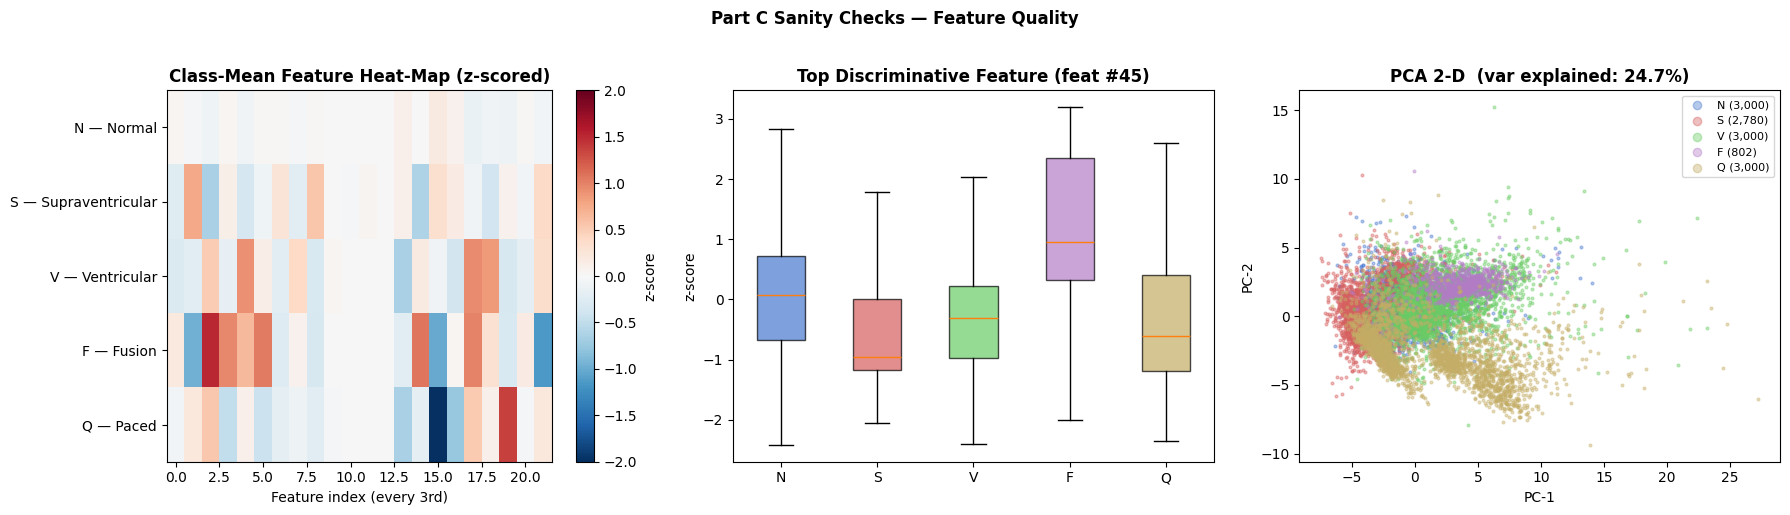


✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\C10_feature_sanity.png
  PCA variance explained (2 components): 24.7%
  Inter-class variance — top feature index: 45  (value: 0.7664)


In [10]:
# C10 — Sanity checks: feature distributions and PCA class projection
# ──────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import Counter

CLASS_FULL   = {0:"Normal", 1:"Supraventricular", 2:"Ventricular", 3:"Fusion", 4:"Paced"}
AAMI_COLORS_LIST = [AAMI_COLORS[AAMI_LABELS[k]] for k in range(5)]

# ── 1. Class distribution ─────────────────────────────────────────────────
dist  = Counter(y_labels.tolist())
total = len(y_labels)
print("AAMI Class Distribution")
print("-" * 44)
for k in range(5):
    n   = dist.get(k, 0)
    bar = "█" * int(25 * n / total)
    print(f"  {AAMI_LABELS[k]} ({CLASS_FULL[k]:<20}) {n:>8,}  {n/total*100:>5.1f}%  {bar}")
print(f"  {'Total':<26} {total:>8,}  100.0%")

# ── 2. Feature mean heat-map (sampled features for readability) ────────────
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
X_scaled = pipe.fit_transform(X_features)

# ← Add this line right after
N_FEATURES = X_scaled.shape[1]

print(f"X_scaled shape: {X_scaled.shape}")
print(f"N_FEATURES updated to: {N_FEATURES}")

# Quick sanity check
print(f"NaNs remaining: {np.isnan(X_scaled).sum()}")  # should print 0

class_means = np.zeros((5, N_FEATURES))
for k in range(5):
    mask = y_labels == k
    if mask.sum() > 0:
        class_means[k] = X_scaled[mask].mean(axis=0)

# Sample every 3rd feature for the heat-map to avoid clutter
feat_idx = np.arange(0, N_FEATURES, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im = axes[0].imshow(class_means[:, feat_idx], aspect="auto", cmap="RdBu_r",
                    vmin=-2, vmax=2)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f"{AAMI_LABELS[k]} — {CLASS_FULL[k]}" for k in range(5)])
axes[0].set_xlabel("Feature index (every 3rd)")
axes[0].set_title("Class-Mean Feature Heat-Map (z-scored)", fontweight="bold")
plt.colorbar(im, ax=axes[0], label="z-score")

# ── 3. Top-5 most discriminative features (by inter-class variance) ────────
inter_var = class_means.var(axis=0)
top5_idx  = np.argsort(inter_var)[::-1][:5]

for plot_i, feat_i in enumerate(top5_idx):
    data_by_class = [X_scaled[y_labels == k, feat_i] for k in range(5)]

bp = axes[1].boxplot(data_by_class,
                     labels=[AAMI_LABELS[k] for k in range(5)],
                     patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], AAMI_COLORS_LIST):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title(f"Top Discriminative Feature (feat #{top5_idx[0]})", fontweight="bold")
axes[1].set_ylabel("z-score")

# ── 4. 2-D PCA projection ─────────────────────────────────────────────────
# Subsample for speed (max 3000 per class)
MAX_PLOT = 3_000
idx_sub  = []
for k in range(5):
    ki = np.where(y_labels == k)[0]
    np.random.shuffle(ki)
    idx_sub.extend(ki[:MAX_PLOT].tolist())
idx_sub = np.array(idx_sub)

pca_2d = PCA(n_components=2, random_state=SEED)
X_2d   = pca_2d.fit_transform(X_scaled[idx_sub])

for k in range(5):
    mask = y_labels[idx_sub] == k
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=4, alpha=0.4, color=AAMI_COLORS_LIST[k],
                    label=f"{AAMI_LABELS[k]} ({mask.sum():,})")
axes[2].set_title(f"PCA 2-D  (var explained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%)",
                  fontweight="bold")
axes[2].set_xlabel("PC-1")
axes[2].set_ylabel("PC-2")
axes[2].legend(fontsize=8, markerscale=3)

plt.suptitle("Part C Sanity Checks — Feature Quality", fontweight="bold", y=1.02)
plt.tight_layout()

out = os.path.join(FIGS_DIR, "C10_feature_sanity.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ Saved {out}")
print(f"  PCA variance explained (2 components): {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Inter-class variance — top feature index: {top5_idx[0]}  (value: {inter_var[top5_idx[0]]:.4f})")

## C11 — Feature Dictionary (All 67 Feature Names)

In [11]:
# C11 — Define and save the full ordered feature name list
# ──────────────────────────────────────────────────────────────────────────
# Used by Part D (MRMR) and Part F (SHAP) to label axes correctly.

feature_names = []

# IMF statistical features (43)
for i in range(1, N_IMFS + 1):
    for stat in ["mean", "std", "energy", "kurtosis", "sample_entropy"]:
        feature_names.append(f"IMF{i}_{stat}")
for g in ["imf1_energy_ratio", "imf23_energy_ratio", "imf48_energy_ratio"]:
    feature_names.append(g)

# Waveform morphology (12)
feature_names += [
    "qrs_amplitude", "qrs_duration_ms", "t_wave_amplitude", "st_deviation",
    "pr_interval_ms", "beat_energy", "zero_crossing_rate", "peak_asymmetry",
    "skewness", "waveform_entropy", "slope_max", "slope_std",
]

# P-wave (8)
feature_names += [
    "p_amplitude", "p_energy", "p_presence", "p_duration_ms",
    "p_area", "p_symmetry", "p_peak_idx", "p_std",
]

# RR interval (4)
feature_names += ["rr_pre", "rr_post", "rr_local", "rr_ratio"]

# ── Drop the same all-NaN columns that were removed from X_features ───────
all_nan_cols = np.where(np.isnan(X_features).all(axis=0))[0]
if len(all_nan_cols) > 0:
    print(f"Dropping all-NaN features: {[feature_names[i] for i in all_nan_cols]}")
    feature_names = [f for i, f in enumerate(feature_names) if i not in all_nan_cols]

# ── Now align N_FEATURES ───────────────────────────────────────────────────
N_FEATURES = len(feature_names)
assert N_FEATURES == X_scaled.shape[1], f"Still mismatched: {N_FEATURES} vs {X_scaled.shape[1]}"
print(f"✓ Feature names: {len(feature_names)}, X_scaled cols: {X_scaled.shape[1]}")
assert len(feature_names) == N_FEATURES, f"Expected {N_FEATURES}, got {len(feature_names)}"

# Save for Parts D and F
import json
with open(os.path.join(SAVE_DIR, "feature_names.json"), "w", encoding="utf-8") as f:
    json.dump(feature_names, f, indent=2)

print(f"✓ Feature dictionary: {len(feature_names)} names saved")
print()
print("  Group          | Indices | Count")
print("  ─────────────────────────────────")
print(f"  IMF statistics |  0 – 42 |  43")
print(f"  Morphology     | 43 – 54 |  12")
print(f"  P-wave         | 55 – 62 |   8")
print(f"  RR interval    | 63 – 66 |   4")
print(f"  ─────────────────────────────────")
print(f"  TOTAL          |  0 – 66 |  67")

Dropping all-NaN features: ['IMF8_kurtosis']
✓ Feature names: 66, X_scaled cols: 66
✓ Feature dictionary: 66 names saved

  Group          | Indices | Count
  ─────────────────────────────────
  IMF statistics |  0 – 42 |  43
  Morphology     | 43 – 54 |  12
  P-wave         | 55 – 62 |   8
  RR interval    | 63 – 66 |   4
  ─────────────────────────────────
  TOTAL          |  0 – 66 |  67


## C12 — Part C Summary & Next Steps

In [12]:
# C12 — Summary
# ──────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Part C Complete — EMD Feature Extraction")
print("=" * 60)
print()
print("  ✓ Constants and Part B arrays reloaded")
print(f"  ✓ EMD decomposition: {N_IMFS} IMFs per beat")
print(f"  ✓ IMF statistical features : 43 dims")
print(f"  ✓ Waveform morphology      : 12 dims")
print(f"  ✓ P-wave features          :  8 dims")
print(f"  ✓ RR interval (from Part B):  4 dims")
print(f"  ✓ Total feature vector     : 67 dims")
print()
print(f"  ✓ NaN / Inf audit passed (median imputation if needed)")
print(f"  ✓ PCA 2-D class separation visualised")
print()
print("  Output files saved to SAVE_DIR:")
print(f"    X_features.npy   — {X_features.shape}   (67-dim feature matrix)")
print(f"    feature_names.json — 67 ordered feature labels")
print()
print("  Next  →  Part D: Inter-patient Split · MRMR · S-SMOTE")
print("             • DS1/DS2 patient-aware split")
print("             • StandardScaler normalisation")
print("             • MRMR top-40 feature selection")
print("             • S-class targeted SMOTE oversampling")
print()
print("=" * 60)

  Part C Complete — EMD Feature Extraction

  ✓ Constants and Part B arrays reloaded
  ✓ EMD decomposition: 8 IMFs per beat
  ✓ IMF statistical features : 43 dims
  ✓ Waveform morphology      : 12 dims
  ✓ P-wave features          :  8 dims
  ✓ RR interval (from Part B):  4 dims
  ✓ Total feature vector     : 67 dims

  ✓ NaN / Inf audit passed (median imputation if needed)
  ✓ PCA 2-D class separation visualised

  Output files saved to SAVE_DIR:
    X_features.npy   — (109432, 67)   (67-dim feature matrix)
    feature_names.json — 67 ordered feature labels

  Next  →  Part D: Inter-patient Split · MRMR · S-SMOTE
             • DS1/DS2 patient-aware split
             • StandardScaler normalisation
             • MRMR top-40 feature selection
             • S-class targeted SMOTE oversampling

